In [2]:
import os
import pandas as pd
import numpy as np
import networkx as nx 
import matplotlib.pyplot as plt
import torch
from networkx.algorithms.community import modularity
from community import community_louvain 


In [3]:
def clean_gt_file_names(importance_ranking):

    """ Gets torch files of ground truth and replaces any old twitter
        usernames with the new ones to match the df_data """

    # Load the DataFrame with member data
    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')

    # Fill NA values in 'new_twitter_name' with values from 'twitter_name'
    members['new_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    # Create a dictionary mapping from the old Twitter names to the new Twitter names
    name_mapping = dict(zip(members['twitter_name'], members['new_twitter_name']))

    # Initialize a new dictionary to hold the updated importance ranking
    updated_importance_ranking = {}

    # Update the dictionary keys
    for old_name, value in importance_ranking.items():
        # Get the new Twitter name if available, otherwise keep the old name
        new_name = name_mapping.get(old_name, old_name)
        updated_importance_ranking[new_name] = value

    # Assign the updated dictionary back to importance_ranking
    return updated_importance_ranking

# Print the updated importance ranking to check
# importance_ranking = torch.load('01_normalized_congress_member_to_affiliation_score.pth')


In [4]:
def assign_strength(df, inflection_point, party_flag):
    """ Assigns 'strong' or 'weak' based on the affiliation score. """
    if party_flag == 'R':
        return 'strong' if df['affiliation_score'] >= inflection_point else 'weak'
    else:  # 'D'
        return 'strong' if df['affiliation_score'] <= inflection_point else 'weak'

In [5]:
def build_bipartite_network(df_data):

    """ Builds directed network using politicians and their followings as nodes
    and directed edges based on if one node follows the other. Used for finding importance
    of websites to filter network """

    G = nx.DiGraph()

    # Add edges based on the politicians and the people they follow
    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']
        following_list = row['following']  # List of people the politician follows
        
        # Add the politician as a node
        G.add_node(politician, party=row['party'])
        
        # Add edges for each person the politician follows
        for followee in following_list:
            G.add_node(followee)  # Add the followed account as a node
            G.add_edge(politician, followee)  # Directed edge from politician to followed account
    
    return G

In [6]:
def build_network(df_data, k, hits, weighted):

    """ Builds network of politicians, with edges between them if they share k followers """

    G = nx.Graph()
    
    # Add nodes
    names = df_data['current_twitter_name'].tolist()

    for _, row in df_data.iterrows():
        politician = row['current_twitter_name']        
        G.add_node(politician, party=row['party'], strength=row['strength'])
    
    # Add edges based on shared following
    for i in range(len(df_data)):
        for j in range(i + 1, len(df_data)):
            # Get the sets of following of each politician
            # Uses the "important_following" column if we incorporate hits, otherwise defaults to the "following" column
            if hits:
                following_i = set(df_data.iloc[i]['important_following'])
                following_j = set(df_data.iloc[j]['important_following'])
            else:
                following_i = set(df_data.iloc[i]['following'])
                following_j = set(df_data.iloc[j]['following'])
            
            # Get the shared following
            shared_following = following_i.intersection(following_j)
            if len(shared_following) >= k:
                if weighted == False:
                    G.add_edge(names[i], names[j])
                else:
                    G.add_edge(names[i], names[j], weight=len(shared_following))
    
    return G

In [17]:
def read_data(num_nodes=-1):

    """ Reads data of politician, their party and who they follow into df_data """

    members = pd.read_csv('raw_data/raw_data/all_congress_members.csv')
    members['current_twitter_name'] = members['new_twitter_name'].fillna(members['twitter_name'])

    df_data = pd.DataFrame()
    df_data[['current_twitter_name','party']] = members[['current_twitter_name','party']].copy()
    if num_nodes != -1:
        df_data = df_data.head(num_nodes)

    following_data = []
    
    for twitter_name in df_data['current_twitter_name']:
        filename = f"twitterExport_{twitter_name}_Following.csv"
        filepath = os.path.join('raw_data/raw_data/following_data_raw', filename)

        if os.path.exists(filepath):
            followed_users = pd.read_csv(filepath)['user_name'].tolist()
        else:
            followed_users = []
        
        following_data.append(followed_users)

    df_data['complete_following'] = following_data
    df_data = df_data[df_data['complete_following'].apply(lambda x: x != [])]

    # Convert the list of all current twitter names to a set for faster lookup
    current_names_set = set(df_data['current_twitter_name'].values)

    # Filter out following names that also appear in df_data['current_twitter_name']
    filtered_following_data = []
    for follow_list in df_data['complete_following']:
        filtered_list = [name for name in follow_list if name not in current_names_set]
        filtered_following_data.append(filtered_list)

    df_data['following'] = filtered_following_data
    df_data = df_data[df_data['following'].apply(lambda x: x != [])]
    
    
    importance_ranking = clean_gt_file_names(torch.load('01_normalized_congress_member_to_affiliation_score.pth'))
    df_data['affiliation_score'] = df_data['current_twitter_name'].map(importance_ranking)
    df_data['strength'] = df_data.apply(lambda x: assign_strength(x, 0.75 if x['party'] == 'R' else -0.75, x['party']), axis=1)
    republican_df = df_data[df_data['party'] == "R"]
    democratic_df = df_data[df_data['party'] == "D"]

    return df_data, republican_df, democratic_df

In [18]:
def degree_lower_2_remover(df_data,G_bipartite):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= 2}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [19]:
def degree_lower_n_remover(df_data,G_bipartite,n):
    degree_centrality = {node: G_bipartite.degree(node) for node in G_bipartite.nodes()}
    # Filtering nodes based on threshold
    filtered_followees = {node for node, score in degree_centrality.items() if score >= n}
    df_data['following'] = df_data['following'].apply(lambda followings: [f for f in followings if f in filtered_followees])


In [20]:
def classify_communities(alignment):
    ratio_list = []
    community_label = {}
    for community_id, parties_total in alignment.items():
        ratio = parties_total['R']/(parties_total['R']+parties_total['D'])
        ratio_list.append(ratio)

    if ratio_list[0]>ratio_list[1]:
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    community_label[Republican] = 'Republican'
    community_label[Democrat] = 'Democrat' 
    # print(ratio_list, community_label)
    return community_label
    

In [21]:
def merge_n_communities_by_edge_count(G, communities, no_communities):
    """Merge a list of communities into exactly n_communities based on the edge counts between them.

    Args:
        G (networkx.Graph): The graph from which the communities are derived.
        communities (list of set): List of communities to merge, where each community is a set of nodes.
        no_communities (int): Desired number of communities after merging.

    Returns:
        list of set: Communities merged based on edge connectivity.
    """
    
    if len(communities) < no_communities:
        raise ValueError("The number of initial communities must be at least equal to the desired number of final communities.")

    # Convert frozensets or other iterables to sets if necessary
    communities = [set(community) for community in communities]

    # Sort communities by size in descending order
    communities = sorted(communities, key=len, reverse=True)

    # Start with the largest communities as determined by 'no_communities'
    largest_communities = communities[:no_communities]
    remaining_communities = communities[no_communities:]

    # Function to count edges between two sets of nodes
    def count_edges_between(set1, set2):
        return sum(1 for node in set1 if set(G.neighbors(node)) & set2)

    # Merge remaining communities into the largest based on edge counts
    for community in remaining_communities:
        max_edges = -1
        best_target_idx = -1

        # Determine which of the largest communities this should merge with
        for i, large_community in enumerate(largest_communities):
            edge_count = count_edges_between(community, large_community)
            if edge_count > max_edges:
                max_edges = edge_count
                best_target_idx = i

        # Merge the community into the best matching largest community
        largest_communities[best_target_idx].update(community)
    return largest_communities


In [22]:
# NEW VERSION CHECK IF WORKS AND THEN TRY IMPLEMENT THE OTHERS

def louvain_two_communities(G):

    """ Run the Louvain algorithm to detect communities """

    partition = community_louvain.best_partition(G)


    initial_communities = {}
    for node, community in partition.items():
        if community not in initial_communities:
            initial_communities[community] = set()
        initial_communities[community].add(node)

    # Convert dictionary of communities into a list of sets
    communities_list = list(initial_communities.values())
    print(len(communities_list))

    # Step 3: Merge communities into two based on edge connectivity
    if len(communities_list) > 2:
        # communities = merge_communities_by_edge_count(G, communities_list)
        communities = merge_n_communities_by_edge_count(G, communities_list, 2)
        # communities = merge_communities_max_modularity(G, communities_list)
        # communities = merge_into_two_communities(communities_list)
    else:
        communities = communities_list
    # Create the final two-community split
    node_to_community = {}
    for node in communities[0]:
        node_to_community[node] = 1
    for node in communities[1]:
        node_to_community[node] = 2

    # Calculate modularity value
    try:
        mod_value = modularity(G, communities)
    except:
        mod_value = 0

    return communities, mod_value

In [33]:
def political_alignment(G, communities):
    """
    Analyze alignment with political parties for a given set of communities.

    Args:
        G (networkx.Graph): The graph from which the communities are derived, with nodes having a 'party' attribute.
        communities (list of set): List of communities, where each community is a set of nodes.

    Returns:
        dict: Dictionary containing the political alignment of each community.
    """
    # Initialize an alignment dictionary for all communities
    alignment = {}
    for idx, community in enumerate(communities, start=1):
        # Initialize party counts for the current community
        alignment[idx] = {'R': 0, 'D': 0}
        for node in community:
            if 'party' in G.nodes[node]:  # Check if the 'party' attribute exists
                party = G.nodes[node]['party']
                if party in alignment[idx]:  # Increment the party count if it's either 'R' or 'D'
                    alignment[idx][party] += 1
                else:  # Optional: initialize other party labels dynamically
                    alignment[idx][party] = 1

    return alignment


In [56]:
def calculate_metrics(alignment, community_label):
    """
    Calculate FFC, ARI, RI, and NMI from alignment data and graph nodes.

    Parameters:
        alignment (dict): Alignment data of communities to political parties.
        node_to_community (dict): Mapping of nodes to their assigned community.
        G (Graph): The graph with nodes and party information.

    Returns:
        dict: Calculated metrics.
    """
    # print(community_label[1])
    if community_label[1] == 'Republican':
        Republican = 1
        Democrat = 2
    else:
        Republican = 2
        Democrat = 1

    # print(Republican, Democrat)
    # Extract counts
    true_positive_R = alignment[Republican]["R"]
    false_positive_R = alignment[Republican]["D"]
    true_positive_D = alignment[Democrat]["D"]
    false_positive_D = alignment[Democrat]["R"]
    # Precision and Recall for R
    precision_R = true_positive_R / (true_positive_R + false_positive_R) if (true_positive_R + false_positive_R) > 0 else 0
    recall_R = true_positive_R / (true_positive_R + false_positive_D) if (true_positive_R + false_positive_D) > 0 else 0
    
    # Precision and Recall for D
    precision_D = true_positive_D / (true_positive_D + false_positive_D) if (true_positive_D + false_positive_D) > 0 else 0
    recall_D = true_positive_D / (true_positive_D + false_positive_R) if (true_positive_D + false_positive_R) > 0 else 0

    # Macro Average (Optional)
    precision_macro = (precision_R + precision_D) / 2
    recall_macro = (recall_R + recall_D) / 2

    f1_score = 2*precision_macro*recall_macro/(precision_macro+recall_macro)  if (precision_macro+recall_macro) > 0 else 0
    accuracy = (true_positive_R+true_positive_D)/(true_positive_D+true_positive_R+false_positive_R+false_positive_D)


    return {
        "accuracy": accuracy,
        "f1": f1_score
    }


In [57]:
df_data, republican_df, democrat_df = read_data(-1)

df_data

,current_twitter_name,party,complete_following,following,affiliation_score,strength
1,SpeakerRyan,R,"[DarrellIssa, WaysandMeansGOP, cathymcmorris, ...","[DarrellIssa, WaysandMeansGOP, RepKevinBrady, ...",0.969697,strong
2,SpeakerPelosi,D,"[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...","[RepAdamSchiff, VP, RepJeffries, FLOTUS, RepSw...",-0.885246,strong
3,michelebachmann,R,"[DavidLimbaugh, RedState, Heritage, ScottWalke...","[DavidLimbaugh, RedState, Heritage, ScottWalke...",0.965217,strong
4,dwstweets,D,"[donnabrazile, Eugene_Robinson, JaredEMoskowit...","[donnabrazile, Eugene_Robinson, JaredEMoskowit...",-0.878049,strong
5,EricCantor,R,"[EWErickson, foxnewspolitics, SpeakerBoehner, ...","[EWErickson, foxnewspolitics, SpeakerBoehner, ...",0.976000,strong
...,...,...,...,...,...,...
176,stabenow,D,"[SenStabenow, SenGaryPeters, gretchenwhitmer, ...","[SenStabenow, SenGaryPeters, gretchenwhitmer, ...",-0.643939,weak
179,sen_joemanchin,D,"[SenatorSinema, lisamurkowski, WVGovernor, Sen...","[SenatorSinema, WVGovernor, SenCapito, SenJoni...",-0.584615,weak
180,sendancoats,R,"[AttyAbdul, lisamurkowski, nkellyIN, marybschn...","[AttyAbdul, nkellyIN, marybschneider, camsavag...",0.707692,weak
181,mcconnellpress,R,"[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...","[LeaderMcConnell, RyanQuarlesKY, KYGOP, SenJoh...",0.628788,weak


In [58]:
G_directed_old = build_bipartite_network(df_data)
degree_lower_n_remover(df_data, G_directed_old, 2)

In [59]:
G = build_network(df_data, 26, False, True)

# 1. Your existing strong nodes
strong_republicans = republican_df[republican_df['strength'] == 'strong']['current_twitter_name'].tolist()
strong_democrats = democrat_df[democrat_df['strength'] == 'strong']['current_twitter_name'].tolist()

weak_republicans = republican_df[republican_df['strength'] == 'weak']['current_twitter_name'].tolist()
weak_democrats = democrat_df[democrat_df['strength'] == 'weak']['current_twitter_name'].tolist()

# 2. Get all republican and democrat nodes
republican_nodes = republican_df['current_twitter_name'].tolist()
democrat_nodes = democrat_df['current_twitter_name'].tolist()

# 3. Build the subgraphs from full network G
G_republican = G.subgraph(republican_nodes).copy()
G_democrat = G.subgraph(democrat_nodes).copy()

G_strong_republican = G.subgraph(strong_republicans).copy()
G_strong_democrat = G.subgraph(strong_democrats).copy()

# 4. Print info about the subgraphs
print(f"Republican Subgraph: {G_republican.number_of_nodes()} nodes, {G_republican.number_of_edges()} edges")
print(f"Democrat Subgraph: {G_democrat.number_of_nodes()} nodes, {G_democrat.number_of_edges()} edges")
print(f"Strong Republican Subgraph: {G_strong_republican.number_of_nodes()} nodes, {G_strong_republican.number_of_edges()} edges")
print(f"Strong Democrat Subgraph: {G_strong_democrat.number_of_nodes()} nodes, {G_strong_democrat.number_of_edges()} edges")


Republican Subgraph: 91 nodes, 3361 edges
Democrat Subgraph: 73 nodes, 1965 edges
Strong Republican Subgraph: 66 nodes, 1886 edges
Strong Democrat Subgraph: 43 nodes, 757 edges


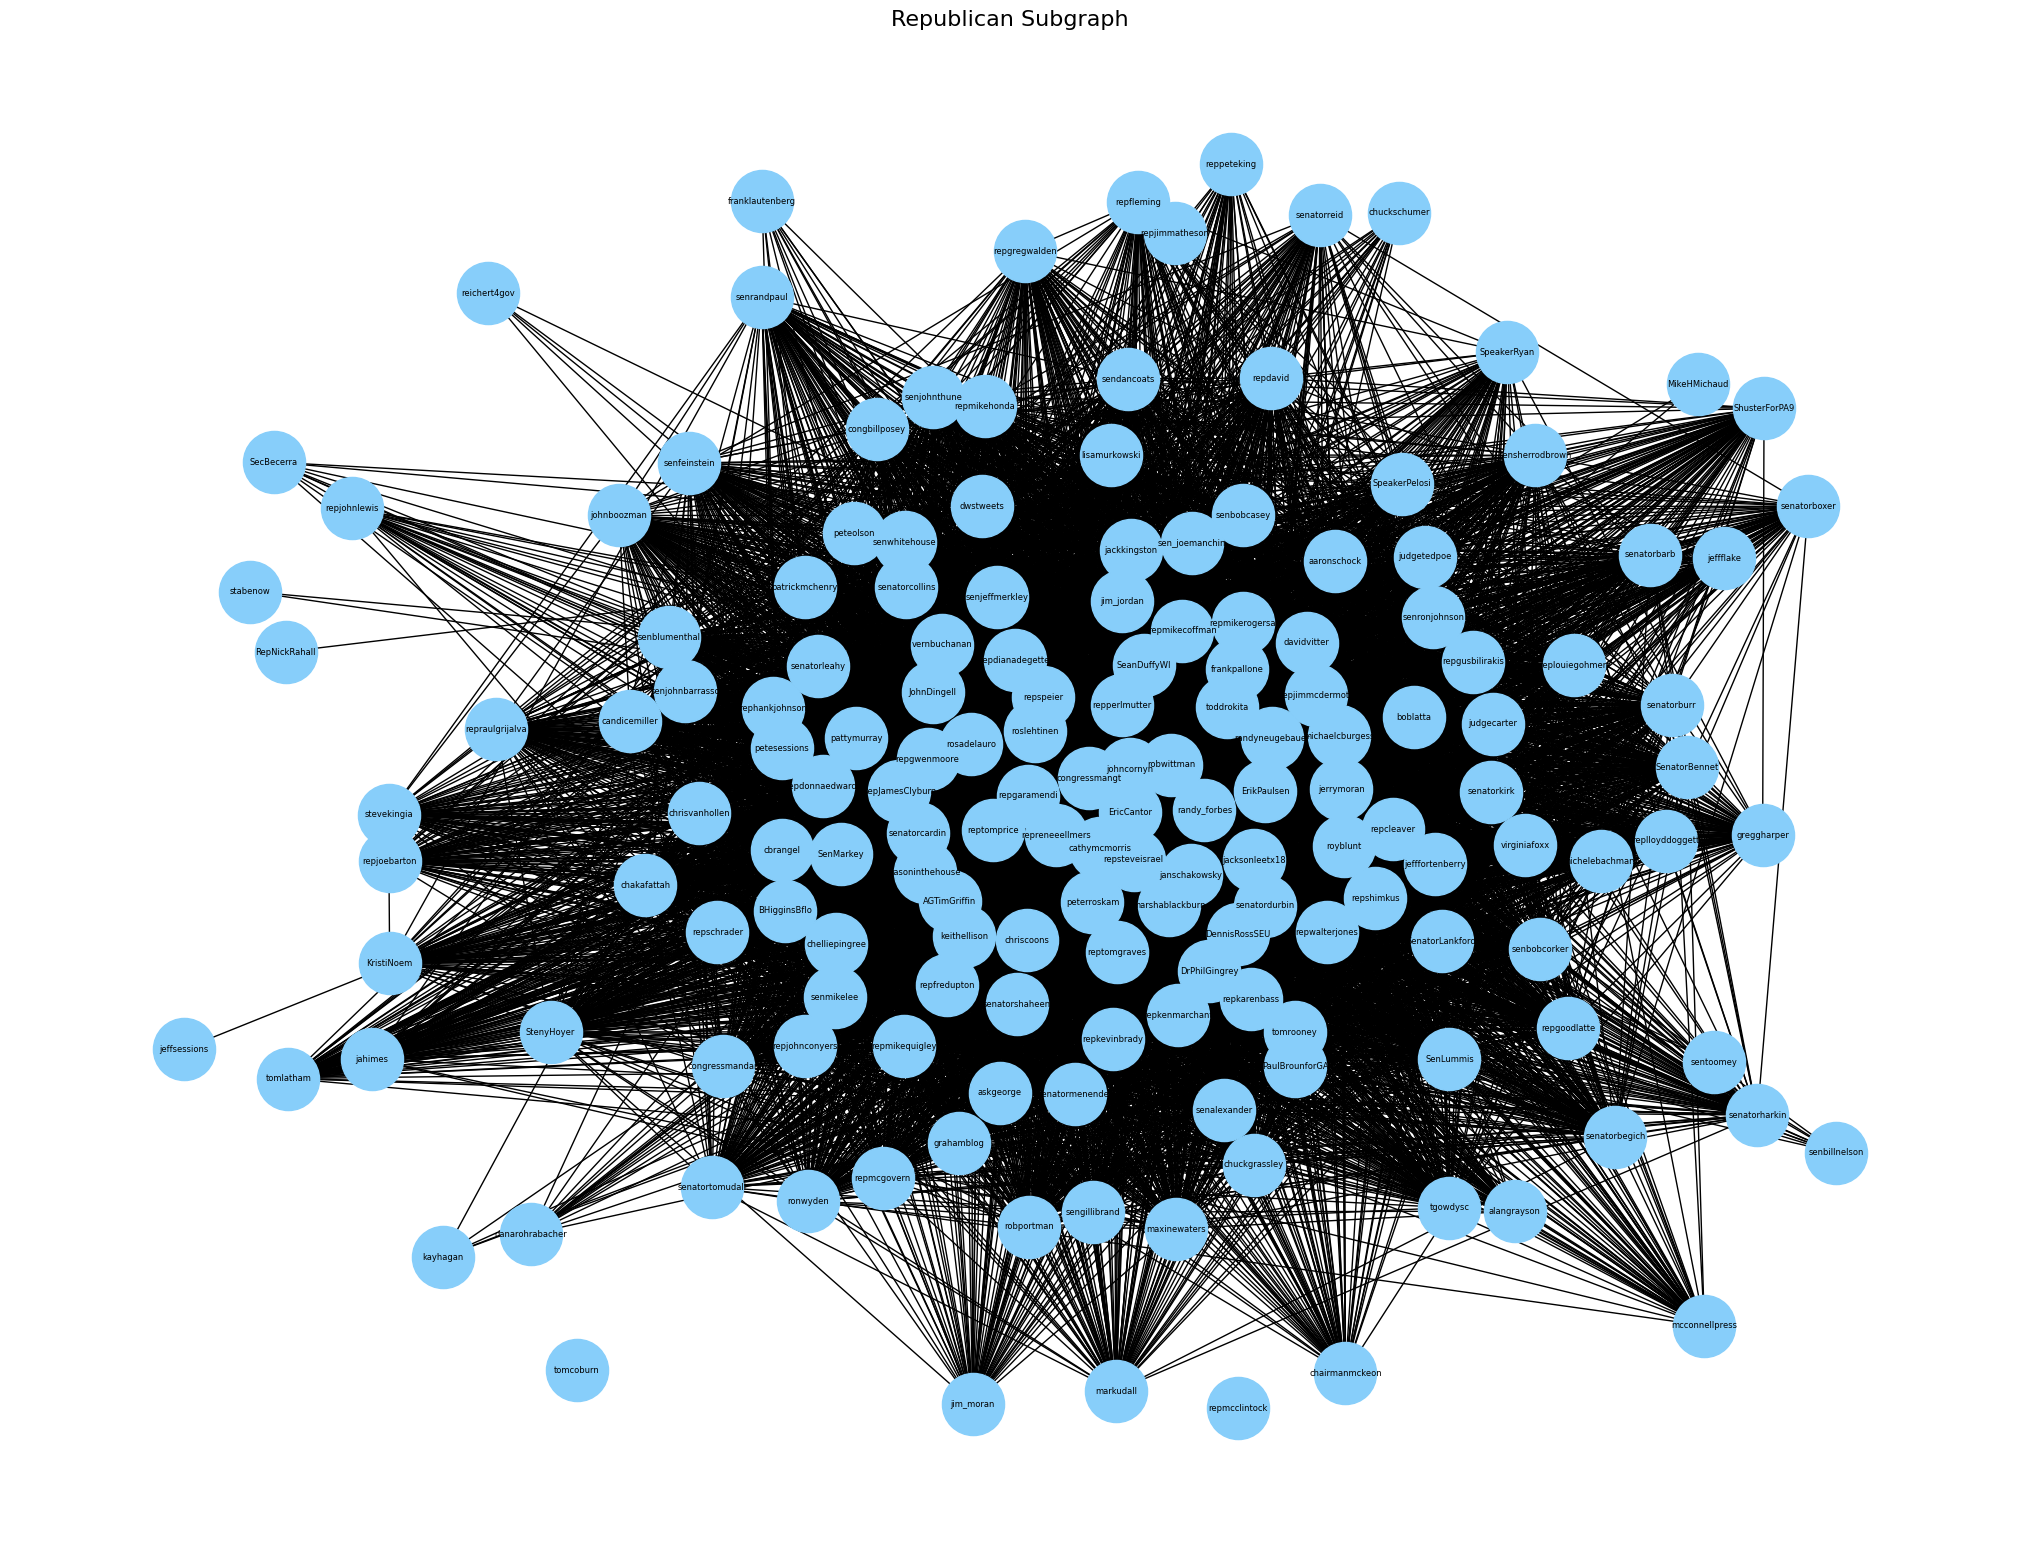

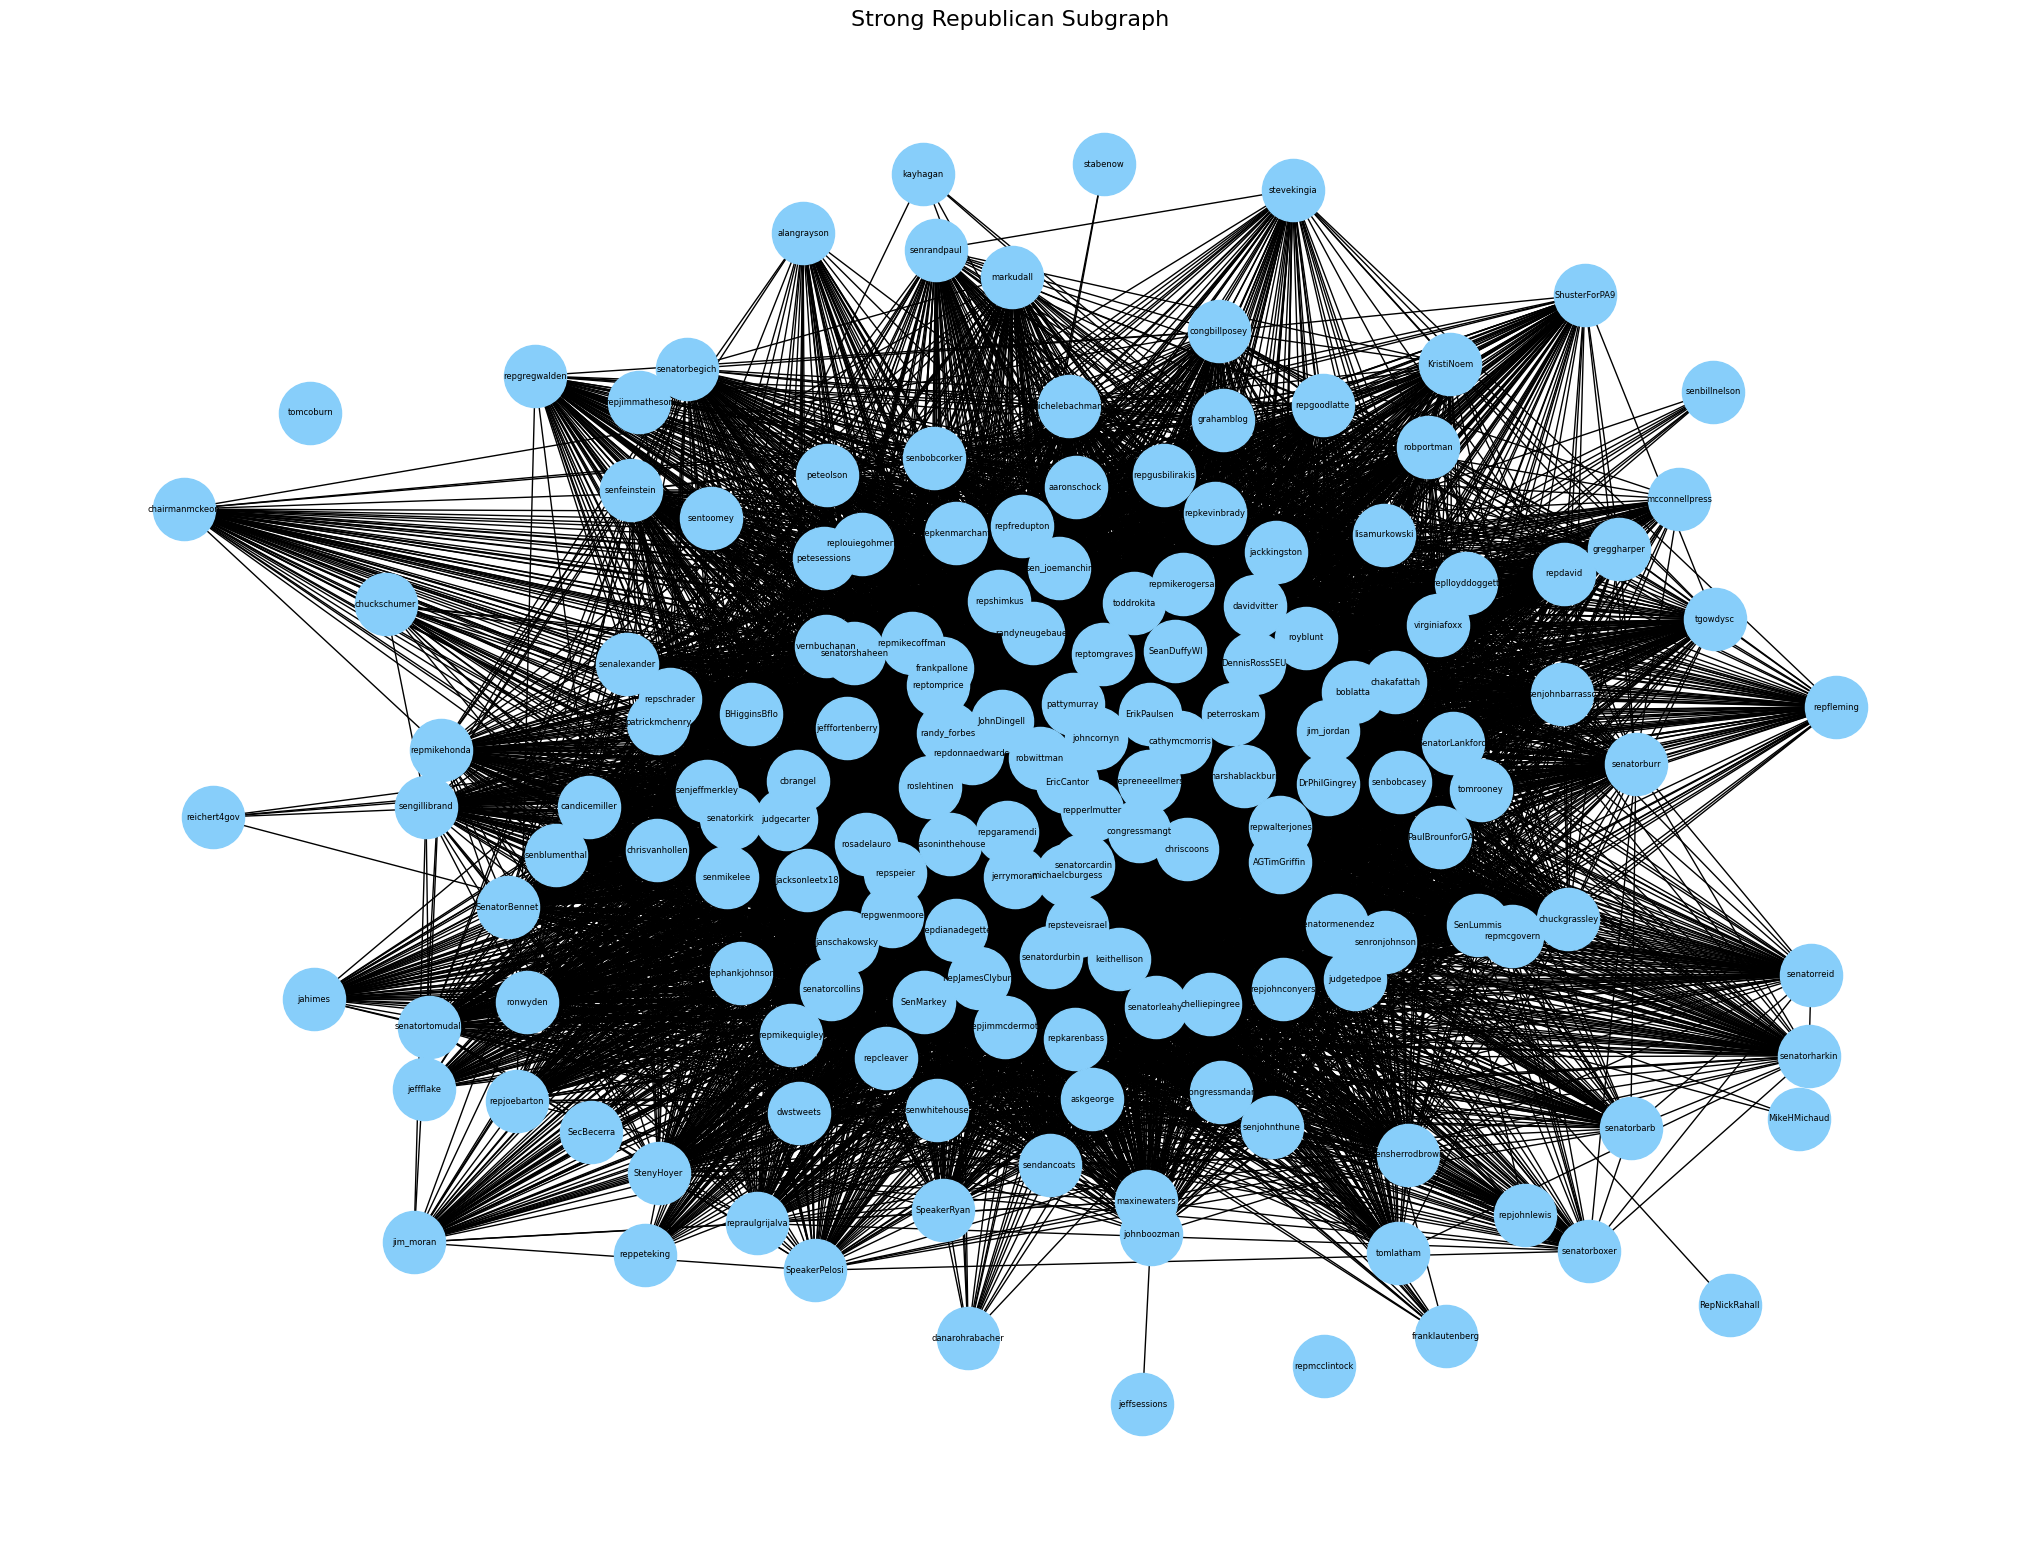

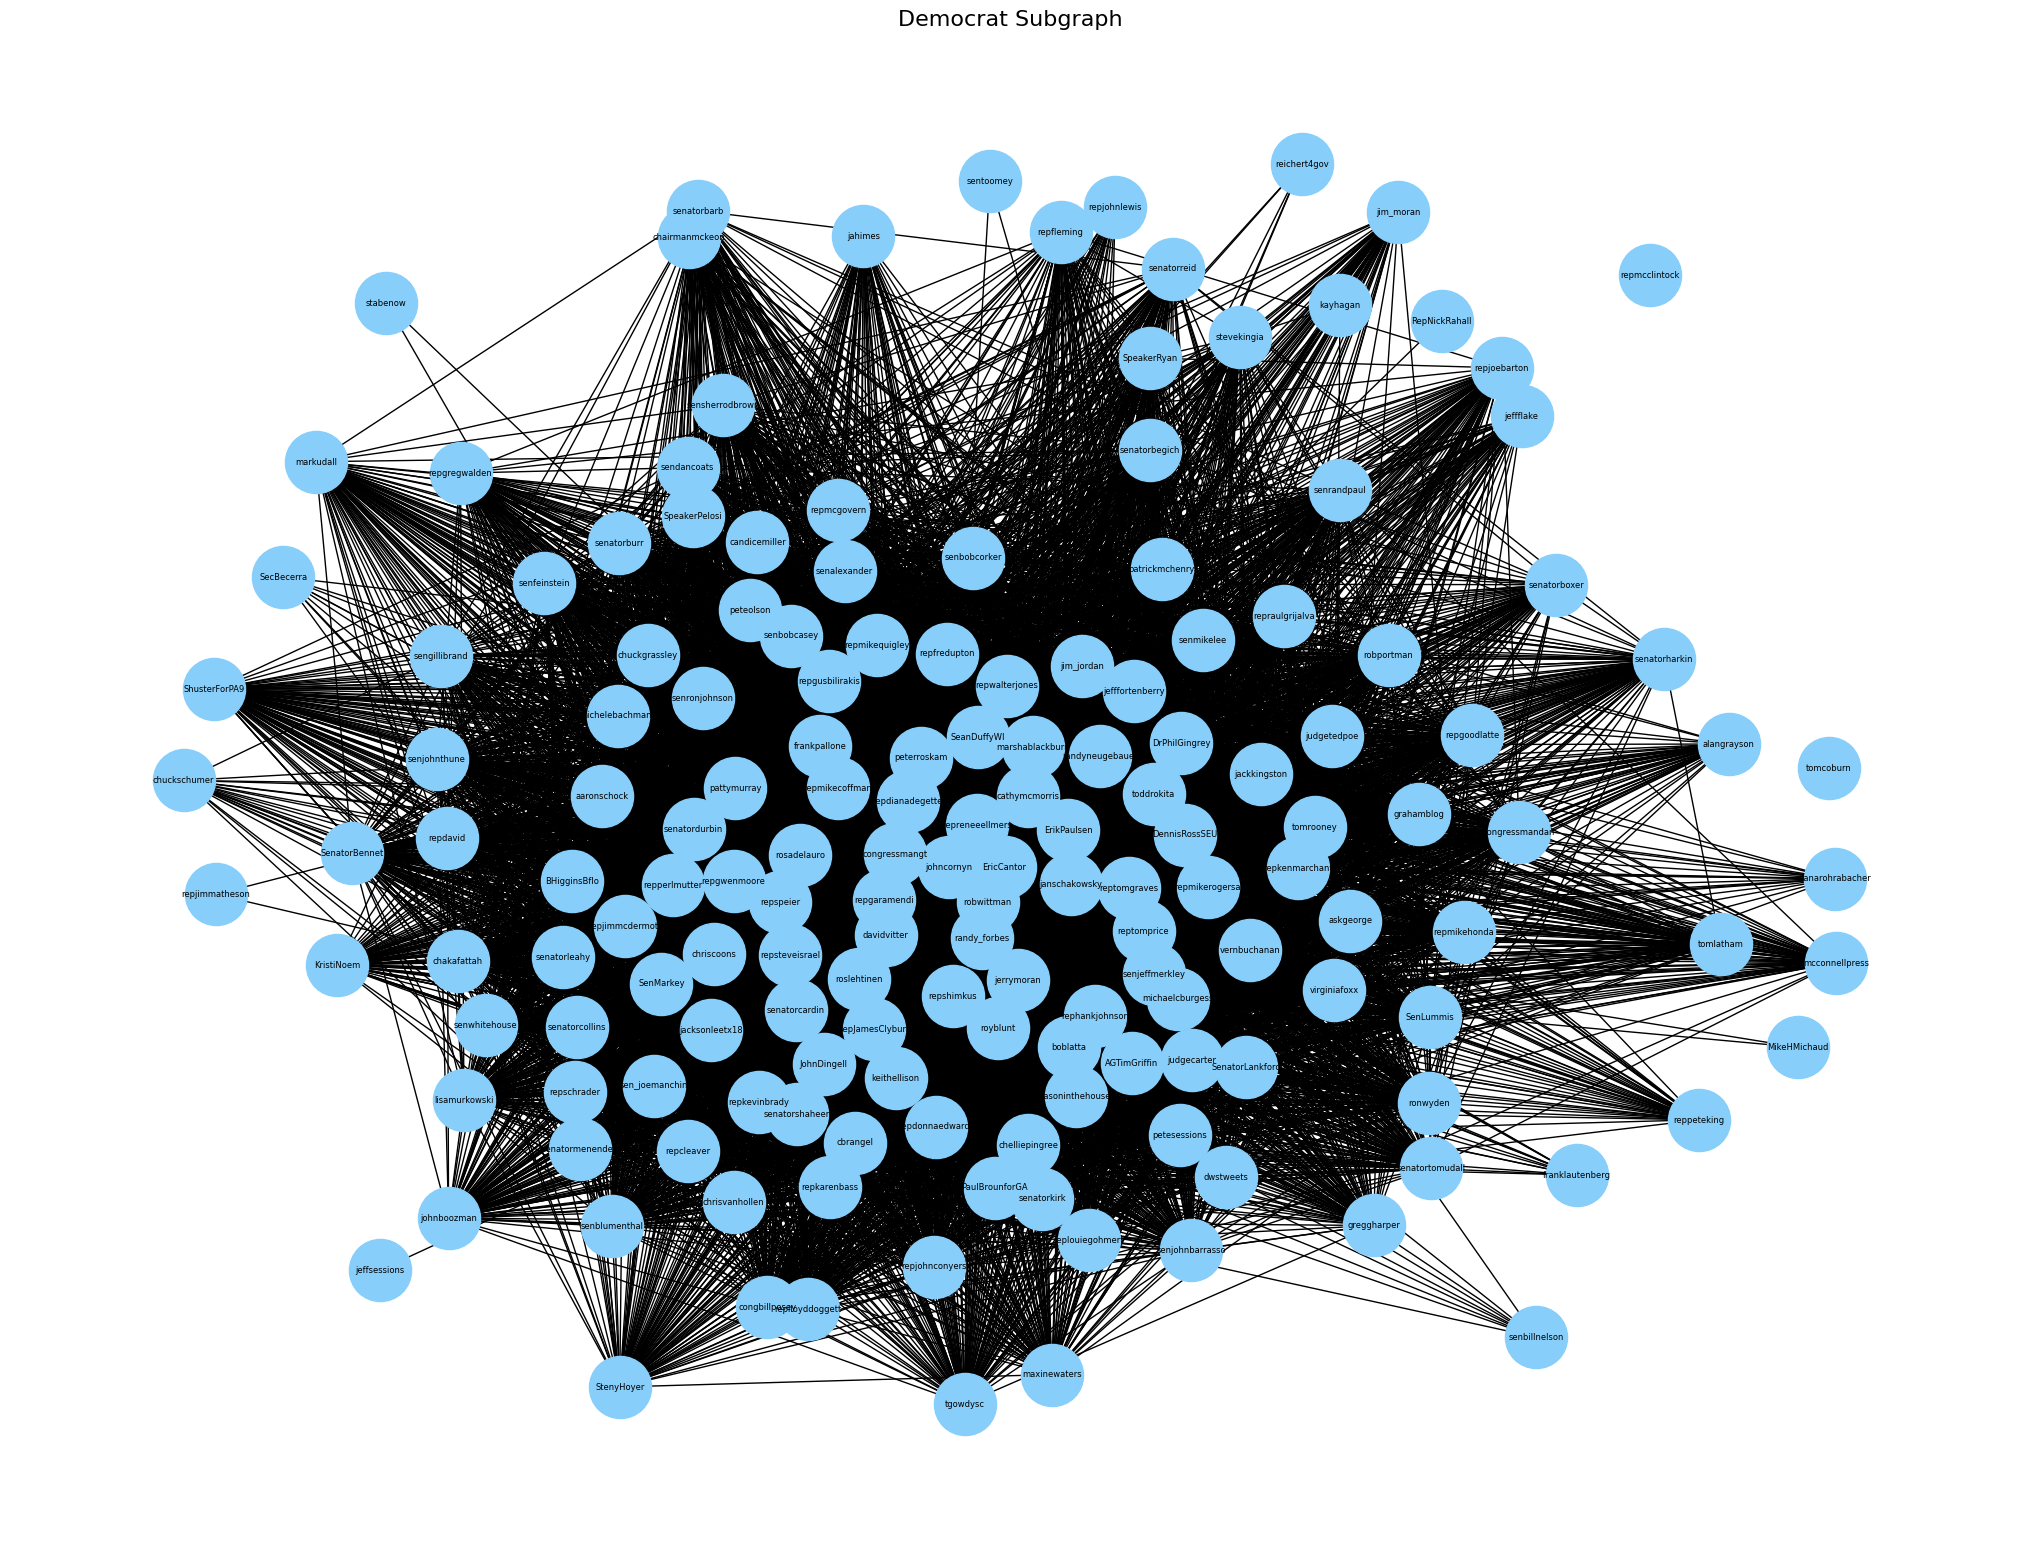

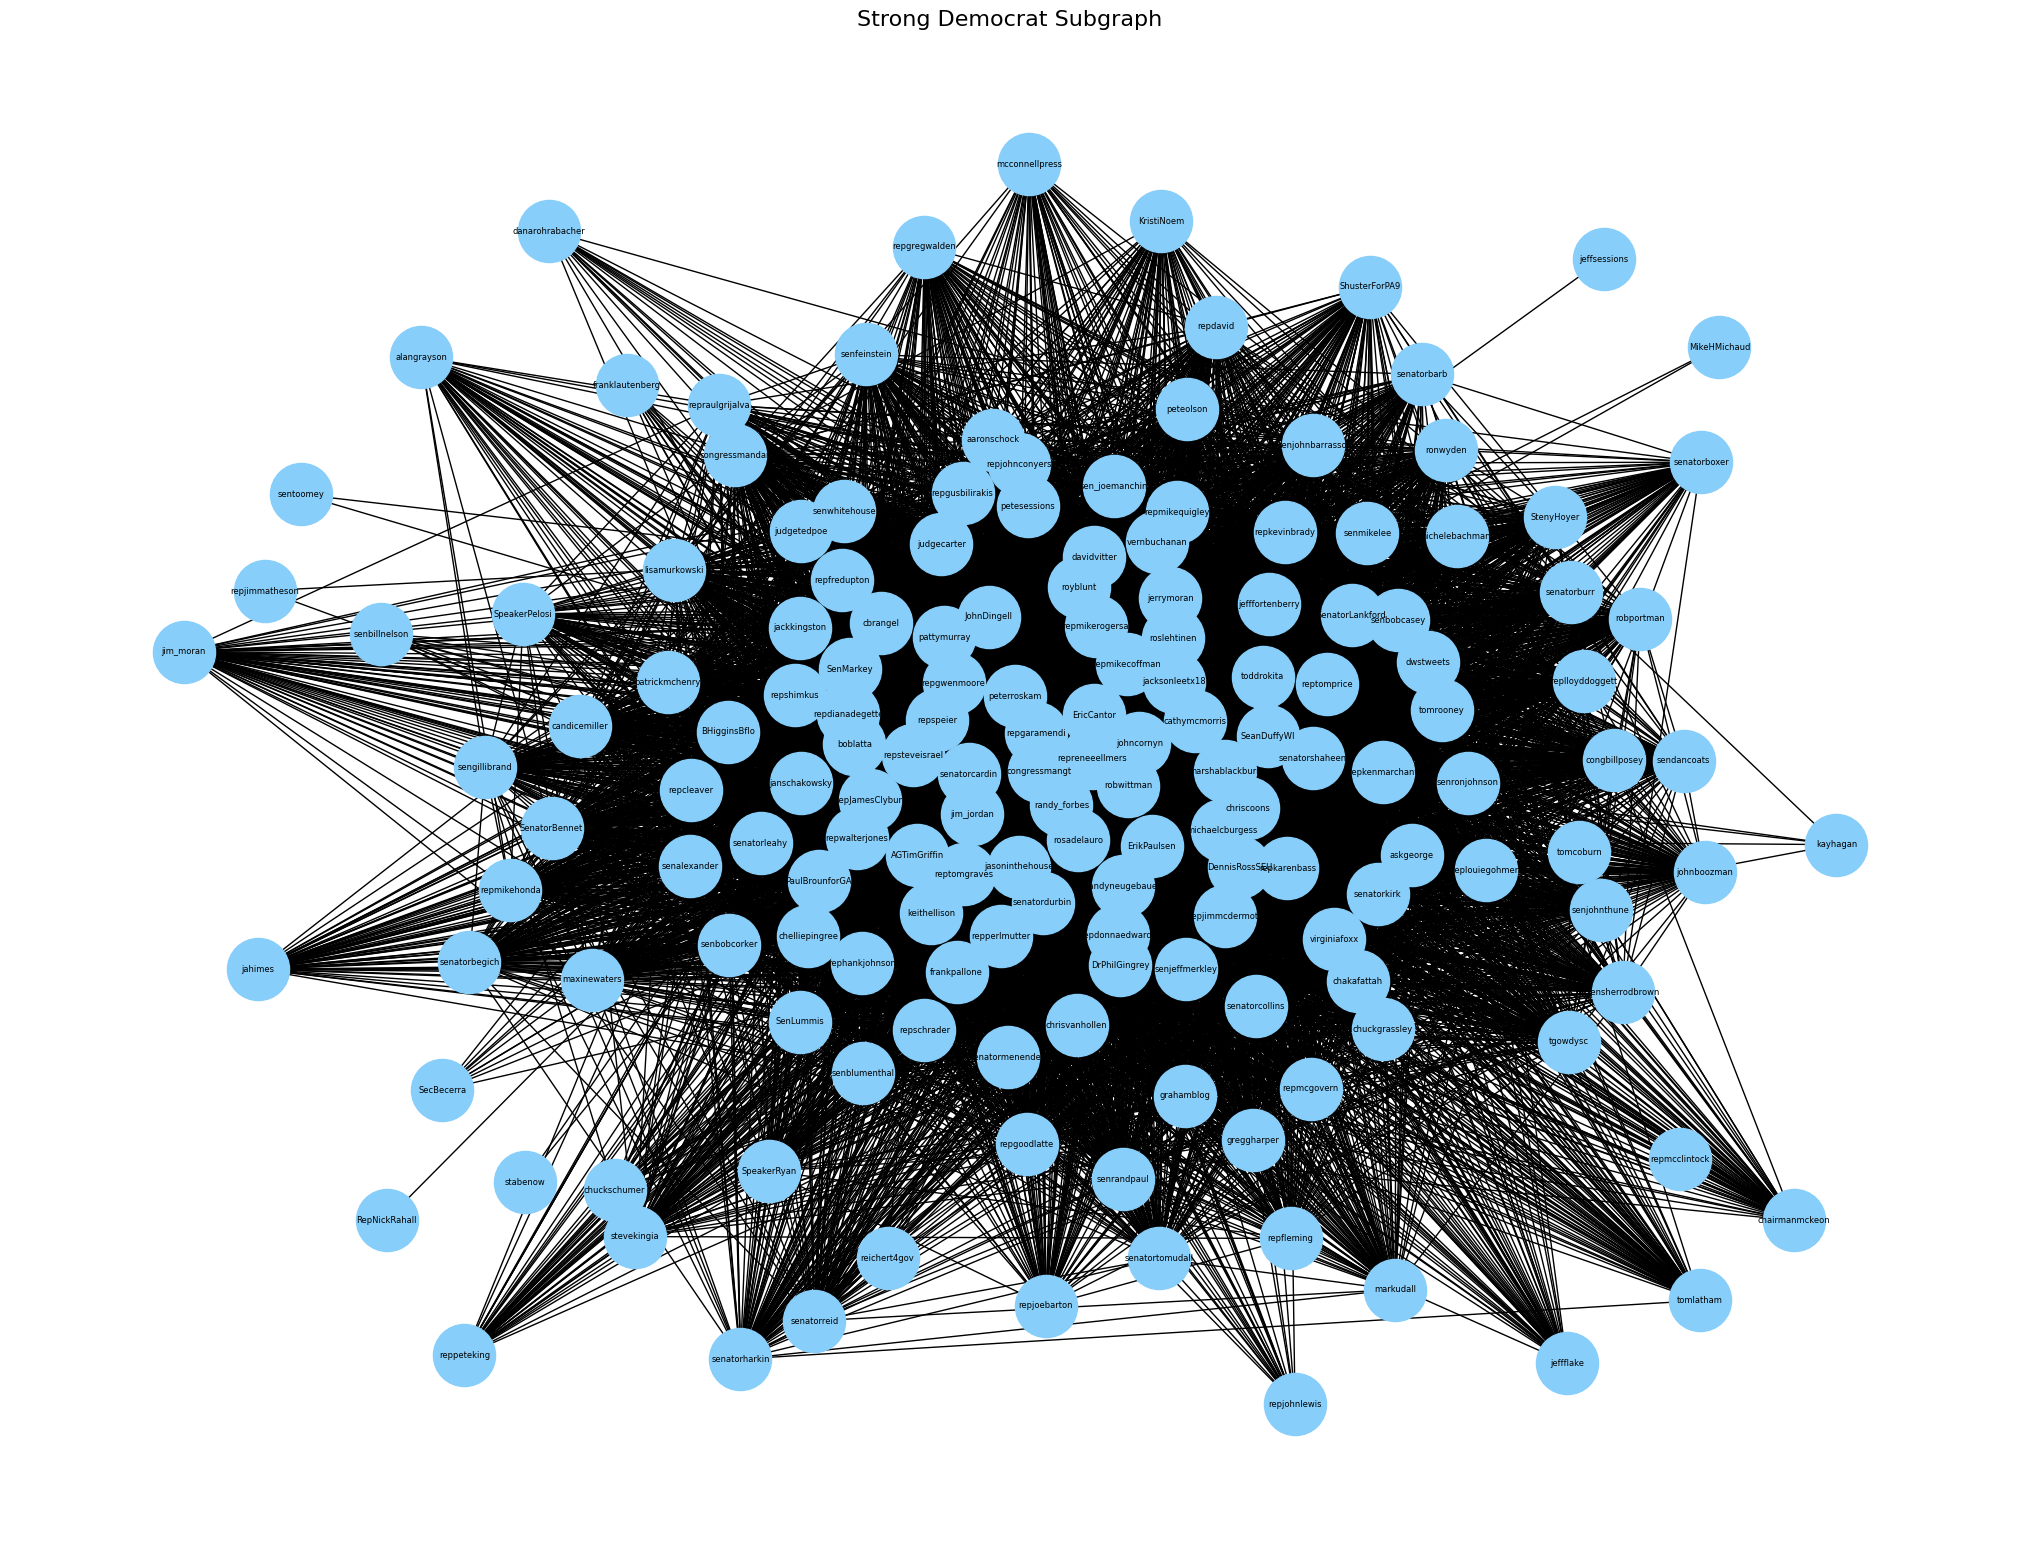

In [60]:
def plot_subgraph(G_sub, title):
    spacing = 65
    plt.figure(figsize=(20, 15))
    # pos = nx.spring_layout(G_sub, seed=42)
    # nx.draw(G_sub, pos, with_labels=True, node_size=300, node_color='skyblue', edge_color='gray')
    # plt.title(title)
    # plt.show()
    pos = nx.spring_layout(G, k=spacing/np.sqrt(len(G.nodes())), iterations=20)
    nx.draw(
        G, pos=pos, with_labels=True, node_color='lightskyblue', node_size=2000, font_size=6
    )
    plt.title(title, fontsize=16)
    plt.show()

# Example usage
plot_subgraph(G_republican, "Republican Subgraph")
plot_subgraph(G_strong_republican, "Strong Republican Subgraph")
plot_subgraph(G_democrat, "Democrat Subgraph")
plot_subgraph(G_strong_democrat, "Strong Democrat Subgraph")


In [61]:
def party_clustering_density_report(G_republican, G_strong_republican, G_democrat, G_strong_democrat):
    print("=== Republican Party ===")
    density_republican = nx.density(G_republican)
    density_strong_republican = nx.density(G_strong_republican)

    clustering_republican = np.mean(list(nx.clustering(G_republican).values()))
    clustering_strong_republican = np.mean(list(nx.clustering(G_strong_republican).values()))

    print(f"Density (All Republicans): {density_republican:.4f}")
    print(f"Density (Strong Republicans Only): {density_strong_republican:.4f}")
    print(f"Avg Clustering Coefficient (All Republicans): {clustering_republican:.4f}")
    print(f"Avg Clustering Coefficient (Strong Republicans Only): {clustering_strong_republican:.4f}")
    print()

    print("=== Democrat Party ===")
    density_democrat = nx.density(G_democrat)
    density_strong_democrat = nx.density(G_strong_democrat)

    clustering_democrat = np.mean(list(nx.clustering(G_democrat).values()))
    clustering_strong_democrat = np.mean(list(nx.clustering(G_strong_democrat).values()))

    print(f"Density (All Democrats): {density_democrat:.4f}")
    print(f"Density (Strong Democrats Only): {density_strong_democrat:.4f}")
    print(f"Avg Clustering Coefficient (All Democrats): {clustering_democrat:.4f}")
    print(f"Avg Clustering Coefficient (Strong Democrats Only): {clustering_strong_democrat:.4f}")
    print()


In [62]:
party_clustering_density_report(
    G_republican, G_strong_republican,
    G_democrat, G_strong_democrat
)


=== Republican Party ===
Density (All Republicans): 0.8208
Density (Strong Republicans Only): 0.8793
Avg Clustering Coefficient (All Republicans): 0.9238
Avg Clustering Coefficient (Strong Republicans Only): 0.9522

=== Democrat Party ===
Density (All Democrats): 0.7477
Density (Strong Democrats Only): 0.8383
Avg Clustering Coefficient (All Democrats): 0.9126
Avg Clustering Coefficient (Strong Democrats Only): 0.9431



In [63]:
import random

def bootstrap_density_clustering_test(G_party, strong_nodes, n_trials=1000):
    """
    Bootstrap test comparing density and clustering coefficient of strong_nodes vs random samples.
    
    Parameters:
        G_party: NetworkX Graph (party subgraph)
        strong_nodes: List of nodes marked as strong
        n_trials: Number of bootstrap samples
    
    Returns:
        Dictionary containing real values, random means, and p-values for both density and clustering coefficient
    """
    all_nodes = list(G_party.nodes())
    n_strong = len(strong_nodes)

    # 1. Real values
    G_strong = G_party.subgraph(strong_nodes)
    real_density = nx.density(G_strong)
    real_clustering = np.mean(list(nx.clustering(G_party, nodes=strong_nodes).values()))

    # 2. Bootstrap samples
    bootstrapped_densities = []
    bootstrapped_clusterings = []

    for _ in range(n_trials):
        sampled_nodes = random.sample(all_nodes, n_strong)
        G_sampled = G_party.subgraph(sampled_nodes)
        density_sampled = nx.density(G_sampled)
        clustering_sampled = np.mean(list(nx.clustering(G_party, nodes=sampled_nodes).values()))

        bootstrapped_densities.append(density_sampled)
        bootstrapped_clusterings.append(clustering_sampled)

    # 3. Calculate p-values
    pval_density = np.mean([d >= real_density for d in bootstrapped_densities])
    pval_clustering = np.mean([c >= real_clustering for c in bootstrapped_clusterings])

    results = {
        'real_density': real_density,
        'mean_random_density': np.mean(bootstrapped_densities),
        'p_value_density': pval_density,
        'real_clustering': real_clustering,
        'mean_random_clustering': np.mean(bootstrapped_clusterings),
        'p_value_clustering': pval_clustering
    }

    return results


In [65]:
# Republicans
results_republican = bootstrap_density_clustering_test(G_republican, strong_republicans)

print("=== Republican Strong Members ===")
print(f"Real Density: {results_republican['real_density']:.4f}")
print(f"Mean Random Density: {results_republican['mean_random_density']:.4f}")
print(f"P-value (Density): {results_republican['p_value_density']:.4f}")

print(f"Real Clustering Coefficient: {results_republican['real_clustering']:.4f}")
print(f"Mean Random Clustering: {results_republican['mean_random_clustering']:.4f}")
print(f"P-value (Clustering): {results_republican['p_value_clustering']:.4f}")

# Similarly for Democrats
results_democrat = bootstrap_density_clustering_test(G_democrat, strong_democrats)
print("=== Democrat Strong Members ===")
print(f"Real Density: {results_democrat['real_density']:.4f}")
print(f"Mean Random Density: {results_democrat['mean_random_density']:.4f}")
print(f"P-value (Density): {results_democrat['p_value_density']:.4f}")

print(f"Real Clustering Coefficient: {results_democrat['real_clustering']:.4f}")
print(f"Mean Random Clustering: {results_democrat['mean_random_clustering']:.4f}")
print(f"P-value (Clustering): {results_democrat['p_value_clustering']:.4f}")


=== Republican Strong Members ===
Real Density: 0.8793
Mean Random Density: 0.8208
P-value (Density): 0.0370
Real Clustering Coefficient: 0.9374
Mean Random Clustering: 0.9243
P-value (Clustering): 0.1940
=== Democrat Strong Members ===
Real Density: 0.8383
Mean Random Density: 0.7432
P-value (Density): 0.0470
Real Clustering Coefficient: 0.9189
Mean Random Clustering: 0.9131
P-value (Clustering): 0.3600


In [44]:
def modularity_strong_vs_weak(G_party, strong_nodes, weak_nodes):
    # 1. Define the community mapping: strong vs weak
    communities = []
    if strong_nodes:
        communities.append(set(strong_nodes))
    if weak_nodes:
        communities.append(set(weak_nodes))
    
    # 2. Compute modularity
    modularity_value = nx.algorithms.community.quality.modularity(G_party, communities)
    return modularity_value

# Example usage:
modularity_republican = modularity_strong_vs_weak(G_republican, strong_republicans, weak_republicans)
modularity_democrat = modularity_strong_vs_weak(G_democrat, strong_democrats, weak_democrats)

print(f"Modularity (Republican: Strong vs Weak): {modularity_republican:.4f}")
print(f"Modularity (Democrat: Strong vs Weak): {modularity_democrat:.4f}")


Modularity (Republican: Strong vs Weak): 0.0163
Modularity (Democrat: Strong vs Weak): 0.0332


In [47]:
from sklearn.metrics import accuracy_score, f1_score
from collections import defaultdict

def evaluate_party_split_with_breakdown(G_party, party_df):
    """
    Evaluate party graph split and show how strong/weak distribute across detected communities.

    Parameters:
        G_party: NetworkX graph (Republican or Democrat only)
        party_df: DataFrame for the party (republican_df or democrat_df)

    Returns:
        accuracy, f1_score, modularity, breakdown (community mapping summary)
    """
    # 1. Run Louvain two-community split
    communities, mod_value = louvain_two_communities(G_party)

    # 2. Build predicted labels
    partition = {}
    for idx, community_nodes in enumerate(communities):
        for node in community_nodes:
            partition[node] = idx  # label 0 or 1 based on detected community

    # 3. Collect true and predicted labels
    y_true = []
    y_pred = []

    for node in G_party.nodes():
        if node in party_df['current_twitter_name'].values:
            strength = party_df.loc[party_df['current_twitter_name'] == node, 'strength'].values[0]
            true_label = 1 if strength == 'strong' else 0
            y_true.append(true_label)
            y_pred.append(partition[node])

    # 4. Accuracy and F1 (with label flipping check)
    acc_raw = accuracy_score(y_true, y_pred)
    f1_raw = f1_score(y_true, y_pred)

    y_pred_flipped = [1 - label for label in y_pred]
    acc_flipped = accuracy_score(y_true, y_pred_flipped)
    f1_flipped = f1_score(y_true, y_pred_flipped)

    best_acc = max(acc_raw, acc_flipped)
    best_f1 = max(f1_raw, f1_flipped)

    # 5. Build Breakdown
    community_counts = {0: {'strong': 0, 'weak': 0}, 1: {'strong': 0, 'weak': 0}}
    
    for node in G_party.nodes():
        if node in party_df['current_twitter_name'].values:
            strength = party_df.loc[party_df['current_twitter_name'] == node, 'strength'].values[0]
            assigned_com = partition[node]
            community_counts[assigned_com][strength] += 1

    # 6. Relabel communities based on majority
    breakdown = {}
    for com, counts in community_counts.items():
        if counts['strong'] >= counts['weak']:
            breakdown['strong community'] = counts
        else:
            breakdown['weak community'] = counts

    return best_acc, best_f1, mod_value, breakdown


In [48]:
acc_r, f1_r, mod_r, breakdown_r = evaluate_party_split_with_breakdown(G_republican, republican_df)
acc_d, f1_d, mod_d, breakdown_d = evaluate_party_split_with_breakdown(G_democrat, democrat_df)

print(f"=== Republican Party ===")
print(f"Accuracy: {acc_r:.4f}")
print(f"F1 Score: {f1_r:.4f}")
print(f"Modularity: {mod_r:.4f}")
print(f"Community Breakdown: {breakdown_r}")

print(f"\n=== Democrat Party ===")
print(f"Accuracy: {acc_d:.4f}")
print(f"F1 Score: {f1_d:.4f}")
print(f"Modularity: {mod_d:.4f}")
print(f"Community Breakdown: {breakdown_d}")


5
4
=== Republican Party ===
Accuracy: 0.6923
F1 Score: 0.7407
Modularity: 0.0341
Community Breakdown: {'strong community': {'strong': 26, 'weak': 23}}

=== Democrat Party ===
Accuracy: 0.8767
F1 Score: 0.8966
Modularity: 0.0404
Community Breakdown: {'strong community': {'strong': 39, 'weak': 5}, 'weak community': {'strong': 4, 'weak': 25}}


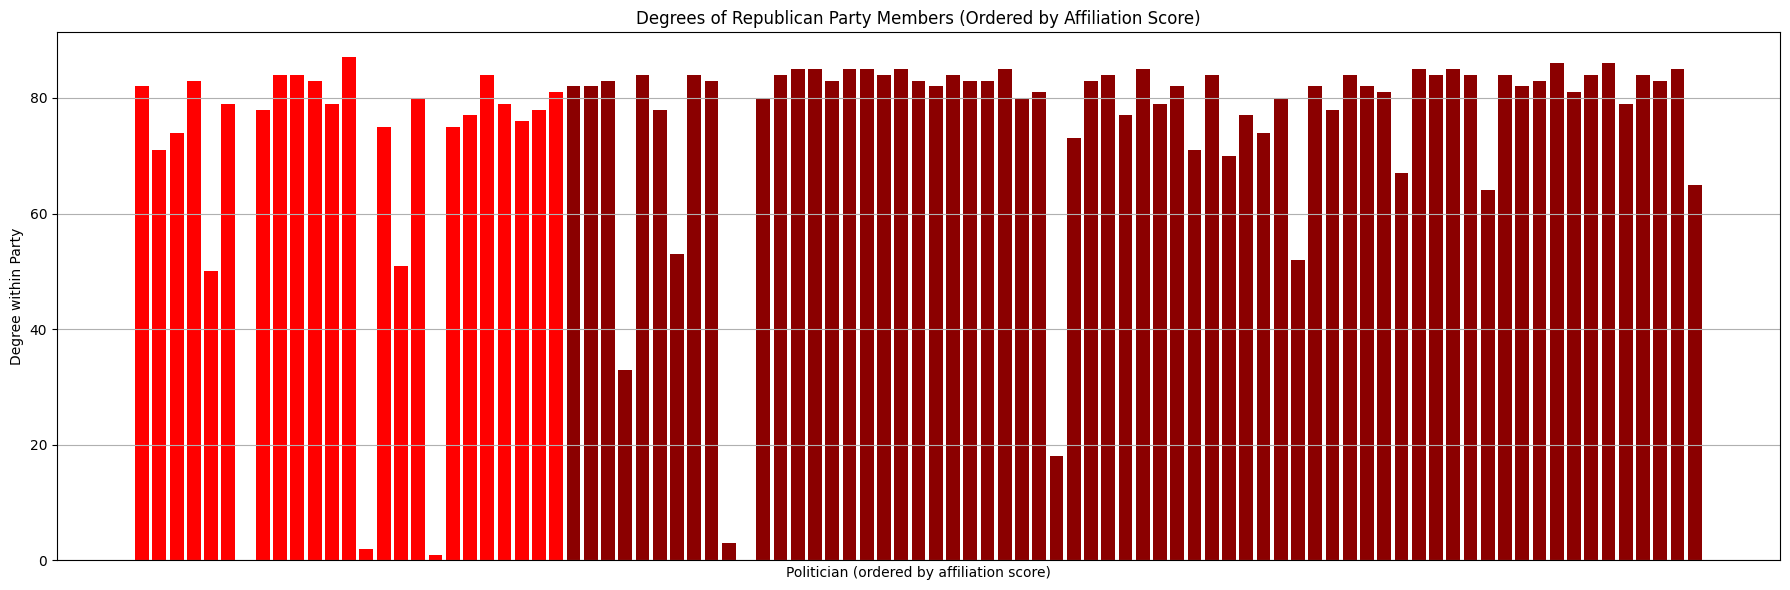

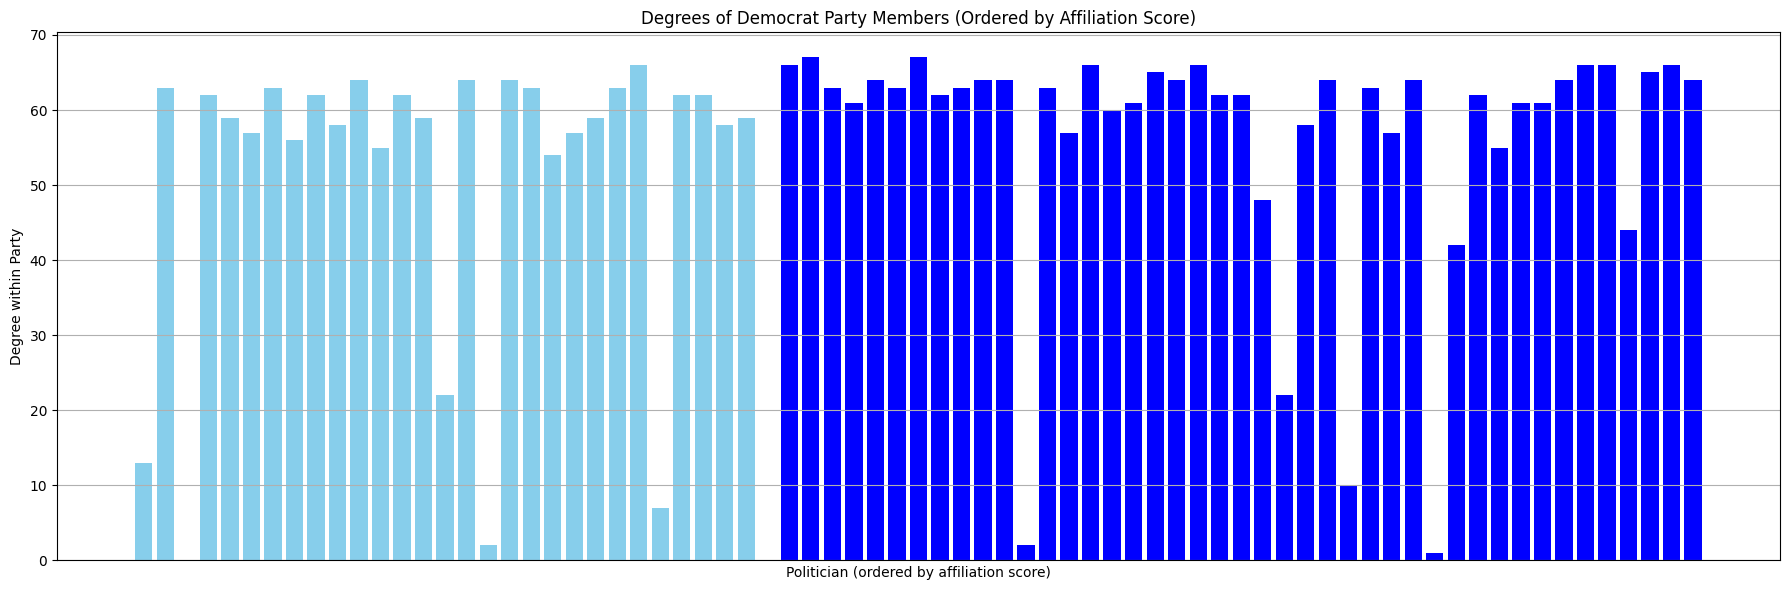

In [68]:

def plot_degrees_by_affiliation(G_party, party_df, party_name):
    """
    G_party: Graph of one party (Republican or Democrat)
    party_df: DataFrame for the party
    party_name: String ('Republican' or 'Democrat')
    """

    # 1. Get degree of each node
    degree_dict = dict(G_party.degree())

    # 2. Merge degrees into the dataframe
    party_df = party_df.copy()
    party_df['degree'] = party_df['current_twitter_name'].map(degree_dict)

    

    # 4. Prepare colors: red for strong, blue for weak
    if party_name == "Republican Party":
        # 3. Sort dataframe by affiliation_score
        party_df_sorted = party_df.sort_values(by='affiliation_score', ascending=True)
        colors = party_df_sorted['strength'].map(lambda x: 'darkred' if x == 'strong' else 'red')
    else:  # Democrat Party
        # 3. Sort dataframe by affiliation_score
        party_df_sorted = party_df.sort_values(by='affiliation_score', ascending=False)
        colors = party_df_sorted['strength'].map(lambda x: 'blue' if x == 'strong' else 'skyblue')

    # 5. Plot
    plt.figure(figsize=(18, 6))
    plt.bar(party_df_sorted['current_twitter_name'], party_df_sorted['degree'], color=colors)
    plt.title(f"Degrees of {party_name} Members (Ordered by Affiliation Score)")
    plt.xlabel("Politician (ordered by affiliation score)")
    plt.ylabel("Degree within Party")
    plt.xticks([], [])  # Hide x-axis labels because too crowded
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

# Example Usage:

plot_degrees_by_affiliation(G_republican, republican_df, "Republican Party")
plot_degrees_by_affiliation(G_democrat, democrat_df, "Democrat Party")


In [73]:
import numpy as np

def calculate_internal_external_degrees(G_full, df_data):
    """
    For each node, calculate internal (same party) and external (cross-party) degrees.
    
    G_full: Full graph (both parties)
    df_data: Full dataframe with 'current_twitter_name', 'party', 'strength'
    
    Returns:
        dict {node: (internal_degree, external_degree)}
    """
    party_map = dict(zip(df_data['current_twitter_name'], df_data['party']))
    internal_external_degrees = {}

    for node in G_full.nodes():
        if node not in party_map:
            continue
        node_party = party_map[node]
        internal = 0
        external = 0
        for neighbor in G_full.neighbors(node):
            if neighbor not in party_map:
                continue
            if party_map[neighbor] == node_party:
                internal += 1
            else:
                external += 1
        internal_external_degrees[node] = (internal, external)

    return internal_external_degrees


def summarize_internal_external(df_data, degrees_dict):
    """
    Calculate mean internal and external degrees for each group: Rstrong, Rweak, Dstrong, Dweak
    """
    # Initialize
    groups = {
        'Rstrong': [],
        'Rweak': [],
        'Dstrong': [],
        'Dweak': []
    }

    for _, row in df_data.iterrows():
        node = row['current_twitter_name']
        party = row['party']
        strength = row['strength']

        if node not in degrees_dict:
            continue

        internal, external = degrees_dict[node]

        if party == 'R' and strength == 'strong':
            groups['Rstrong'].append((internal, external))
        elif party == 'R' and strength == 'weak':
            groups['Rweak'].append((internal, external))
        elif party == 'D' and strength == 'strong':
            groups['Dstrong'].append((internal, external))
        elif party == 'D' and strength == 'weak':
            groups['Dweak'].append((internal, external))

    # Calculate means
    results = {}
    for group, degrees in groups.items():
        if degrees:
            internals, externals = zip(*degrees)
            results[group] = {
                'mean_internal': np.mean(internals),
                'mean_external': np.mean(externals)
            }
        else:
            results[group] = {
                'mean_internal': None,
                'mean_external': None
            }

    return results, groups


In [74]:
# 1. First calculate degrees
internal_external_degrees = calculate_internal_external_degrees(G, df_data)

# 2. Then summarize
summary, groups = summarize_internal_external(df_data, internal_external_degrees)

# 3. Print nicely
for group, metrics in summary.items():
    print(f"=== {group} ===")
    print(f"Mean Internal Degree: {metrics['mean_internal']:.2f}")
    print(f"Mean External Degree: {metrics['mean_external']:.2f}\n")


=== Rstrong ===
Mean Internal Degree: 76.20
Mean External Degree: 44.61

=== Rweak ===
Mean Internal Degree: 67.72
Mean External Degree: 43.72

=== Dstrong ===
Mean Internal Degree: 56.63
Mean External Degree: 59.88

=== Dweak ===
Mean Internal Degree: 49.83
Mean External Degree: 48.73



In [75]:
import numpy as np
import random

def bootstrap_test_internal_external(strong_degrees, weak_degrees, n_trials=10000):
    """
    Bootstrap test comparing mean internal and external degrees between strong and weak groups.

    Parameters:
        strong_degrees: list of (internal, external) tuples for strong members
        weak_degrees: list of (internal, external) tuples for weak members
        n_trials: number of bootstrap samples

    Returns:
        dict containing real differences and p-values for internal and external degree comparisons
    """

    # 1. Extract real means
    strong_internal, strong_external = zip(*strong_degrees)
    weak_internal, weak_external = zip(*weak_degrees)

    real_internal_diff = np.mean(strong_internal) - np.mean(weak_internal)
    real_external_diff = np.mean(strong_external) - np.mean(weak_external)

    # 2. Bootstrap
    combined_internal = list(strong_internal) + list(weak_internal)
    combined_external = list(strong_external) + list(weak_external)

    n_strong = len(strong_internal)
    n_weak = len(weak_internal)

    boot_internal_diffs = []
    boot_external_diffs = []

    for _ in range(n_trials):
        resample = random.sample(list(zip(combined_internal, combined_external)), n_strong + n_weak)
        resample_internal = [pair[0] for pair in resample]
        resample_external = [pair[1] for pair in resample]

        strong_sample_internal = resample_internal[:n_strong]
        weak_sample_internal = resample_internal[n_strong:]

        strong_sample_external = resample_external[:n_strong]
        weak_sample_external = resample_external[n_strong:]

        boot_internal_diffs.append(np.mean(strong_sample_internal) - np.mean(weak_sample_internal))
        boot_external_diffs.append(np.mean(strong_sample_external) - np.mean(weak_sample_external))

    # 3. Calculate p-values
    pval_internal = np.mean([diff >= real_internal_diff for diff in boot_internal_diffs])
    pval_external = np.mean([diff >= real_external_diff for diff in boot_external_diffs])

    return {
        'real_internal_diff': real_internal_diff,
        'pval_internal': pval_internal,
        'real_external_diff': real_external_diff,
        'pval_external': pval_external
    }


In [76]:
# Prepare the groups manually first
# Suppose you already have:

# groups = {
#     'Rstrong': [...],
#     'Rweak': [...],
#     'Dstrong': [...],
#     'Dweak': [...]
# }

# Republicans
results_republican = bootstrap_test_internal_external(groups['Rstrong'], groups['Rweak'])

print("=== Republican Party ===")
print(f"Internal Degree Difference: {results_republican['real_internal_diff']:.2f}")
print(f"P-value (Internal): {results_republican['pval_internal']:.4f}")
print(f"External Degree Difference: {results_republican['real_external_diff']:.2f}")
print(f"P-value (External): {results_republican['pval_external']:.4f}")

# Democrats
results_democrat = bootstrap_test_internal_external(groups['Dstrong'], groups['Dweak'])

print("\n=== Democrat Party ===")
print(f"Internal Degree Difference: {results_democrat['real_internal_diff']:.2f}")
print(f"P-value (Internal): {results_democrat['pval_internal']:.4f}")
print(f"External Degree Difference: {results_democrat['real_external_diff']:.2f}")
print(f"P-value (External): {results_democrat['pval_external']:.4f}")


=== Republican Party ===
Internal Degree Difference: 8.48
P-value (Internal): 0.0489
External Degree Difference: 0.89
P-value (External): 0.4176

=== Democrat Party ===
Internal Degree Difference: 6.79
P-value (Internal): 0.0733
External Degree Difference: 11.15
P-value (External): 0.0540


In [ ]:
s